In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)

In [ ]:
df = pd.read_csv('clean_data_de_a_devis3.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
df.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,4165.000000,4165.000000,4165.000000,4165.000000,4165.000000,4165.0,4165.000000
mean,2013.540936,52351.855702,19.436039,1396.140961,96.642520,5.0,5.902473
std,2.879516,26038.055885,3.684670,344.186679,33.143338,0.0,3.771794
min,2006.000000,171.000000,8.700000,72.000000,34.200000,5.0,0.690000
25%,2012.000000,33000.000000,17.000000,1197.000000,74.000000,5.0,3.300000
50%,2014.000000,51361.000000,19.100000,1298.000000,86.800000,5.0,4.900000
75%,2016.000000,69000.000000,22.070000,1499.000000,110.400000,5.0,7.100000
max,2019.000000,131000.000000,28.400000,2997.000000,224.340000,5.0,20.280000


Cantidad de vehículos eléctricos: 2


<ipython-input-4-c1e9be879b07>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  series[series.isin(otros_valores)] = 'Otros'
<ipython-input-4-c1e9be879b07>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  series[series.isin(otros_valores)] = 'Otros'


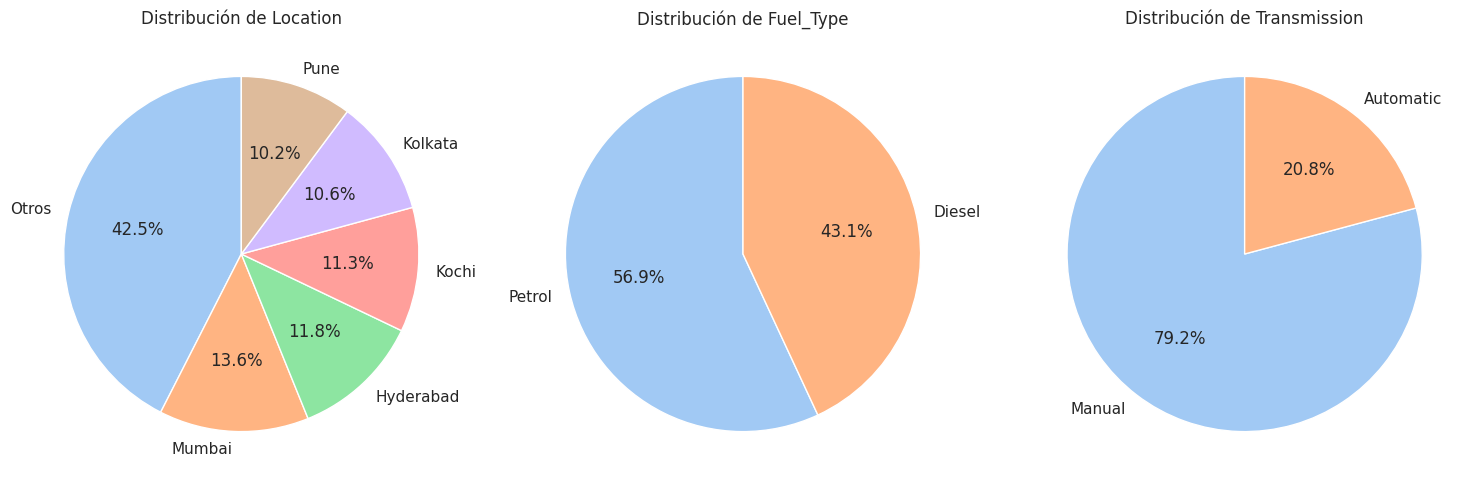

In [ ]:
# Columnas categóricas a graficar
categorical_cols = ["Location", "Fuel_Type", "Transmission"]
#Contar la cantidad de Electric en Fuel_Type
electric_count = df['Fuel_Type'].value_counts().get('Electric', 0)
print(f"Cantidad de vehículos eléctricos: {electric_count}")
# Crear subgráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # Ajustado a 3 columnas
#Creamos un threshold del 10% para las locaciones
location_threshold = 0.1 * len(df)
def otros(series, threshold):
  cantidad = series.value_counts()
  mask = cantidad < threshold
  otros_valores = cantidad[mask].index
  series[series.isin(otros_valores)] = 'Otros'
  return series
df['Location'] = otros(df['Location'], location_threshold)

# Iterar sobre las columnas categóricas0
# Generar gráficas de pastel
for ax, col in zip(axes.flatten(), categorical_cols):
    if col == "Location":
        df[col] = otros(df[col], location_threshold)
    elif col == "Fuel_Type":
        df = df[df["Fuel_Type"] != "Electric"]  # Eliminar carros eléctricos
    data = df[col].value_counts()
    colors = sns.color_palette("pastel", len(data))
    ax.pie(data, labels=data.index, autopct="%1.1f%%", startangle=90, colors=colors)
    ax.set_title(f"Distribución de {col}")

# Ajustar diseño
plt.tight_layout()
plt.show()

Cantidad de carros con Fourth & Above Owner: 5


<ipython-input-5-52b9f2b9e977>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Owner_Type"], palette="pastel")


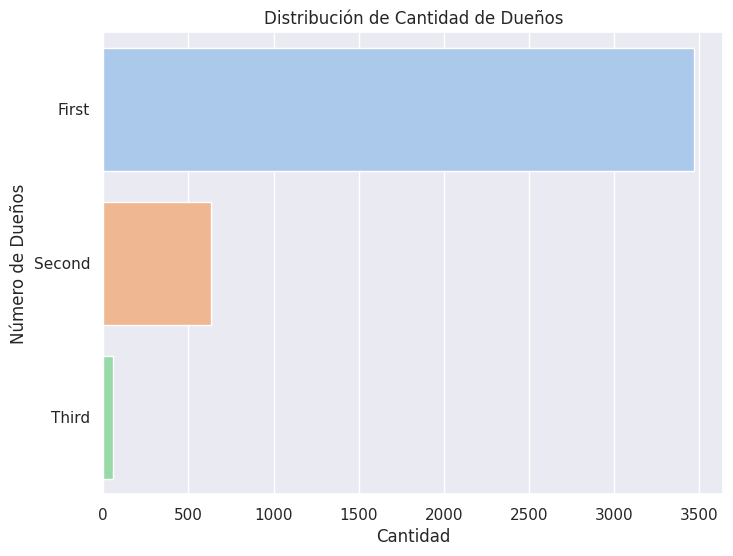

In [ ]:
#Cantidad de Fourth and above
Cantidad_4 = df["Owner_Type"].value_counts().get("Fourth & Above", 0)
print(f"Cantidad de carros con Fourth & Above Owner: {Cantidad_4}")
#Eliminamos Fourth & Above
df = df[df["Owner_Type"] != "Fourth & Above"]
plt.figure(figsize=(8, 6))
sns.countplot(y=df["Owner_Type"], palette="pastel")
plt.title("Distribución de Cantidad de Dueños")
plt.xlabel("Cantidad")
plt.ylabel("Número de Dueños")
plt.show()

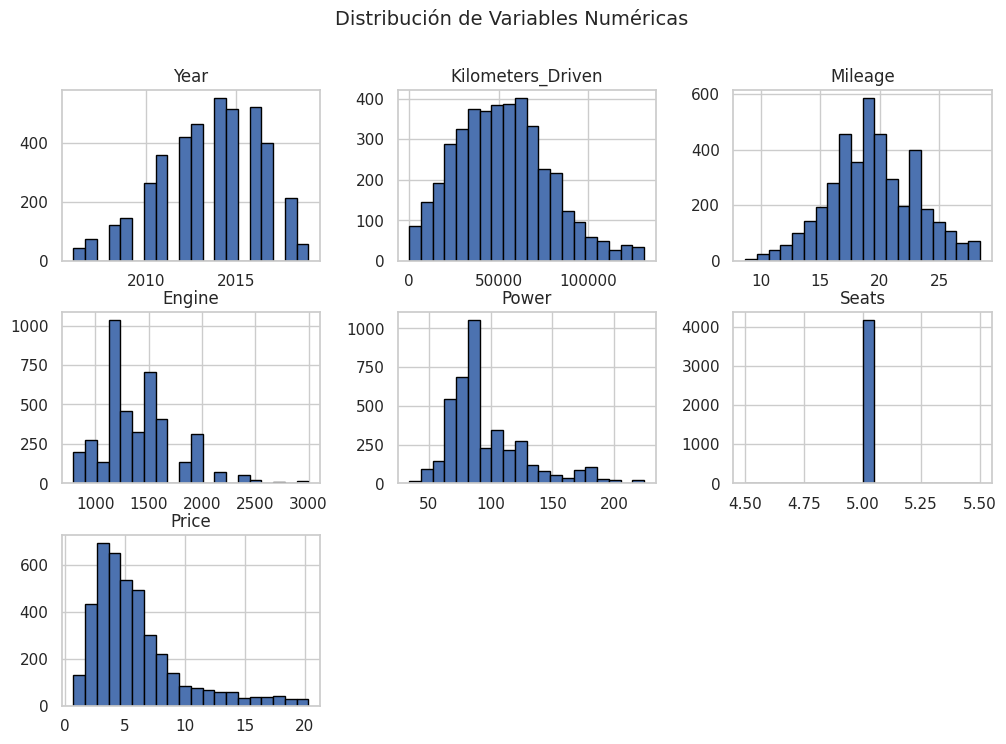

In [ ]:
# Convertir columnas con valores numéricos almacenados como strings
df['Mileage'] = df['Mileage'].astype(str).str.extract("([0-9.]+)").astype(float)
df['Engine'] = df['Engine'].astype(str).str.replace(' CC', '', regex=True).astype(float)
df['Power'] = df['Power'].astype(str).str.replace(' bhp', '', regex=True).astype(float)
#df.drop(columns=['Unnamed: 0'], inplace=True)
# Crear una copia limpia sin eliminar columnas categóricas
df_clean = df.copy()

# Configuración de estilo
sns.set_style("whitegrid")

# 1. Histogramas de variables numéricas
df_clean.hist(figsize=(12, 8), bins=20, edgecolor='black')
plt.suptitle("Distribución de Variables Numéricas", fontsize=14)
plt.show()

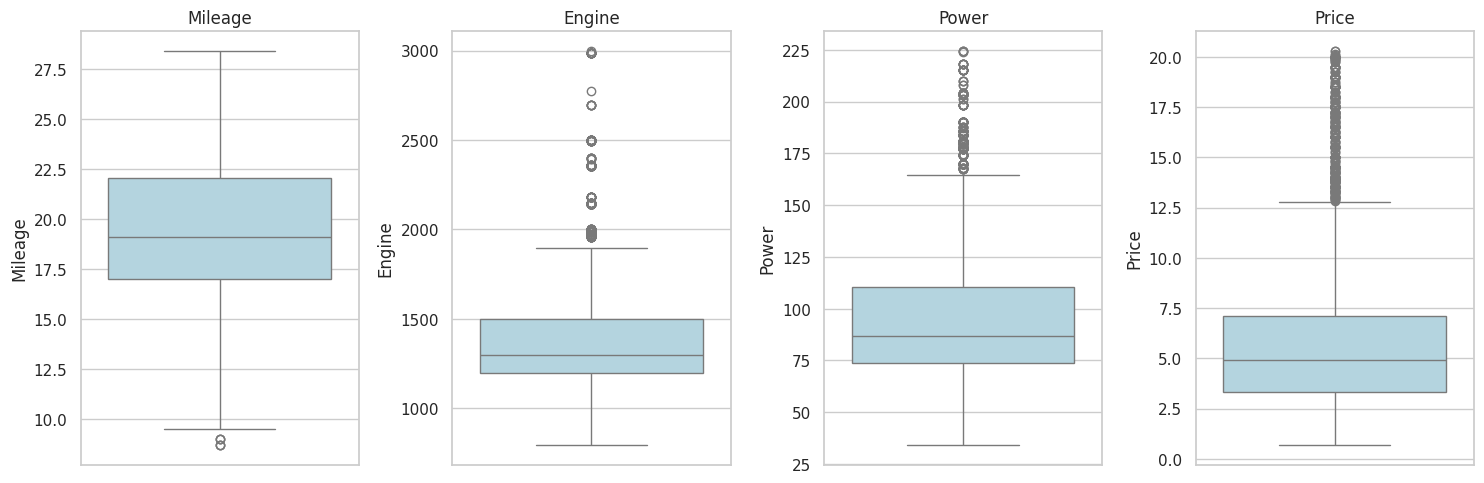

In [ ]:
boxplot_columns = ["Mileage", "Engine", "Power", "Price"]

# Crear subgráficos en un solo gráfico
fig, axes = plt.subplots(nrows=1, ncols=len(boxplot_columns), figsize=(15, 5))

# Generar boxplots para cada variable
for ax, col in zip(axes, boxplot_columns):
    sns.boxplot(y=df_clean[col], ax=ax, color="lightblue")
    ax.set_title(col)

# Ajustar diseño
plt.tight_layout()
plt.show()

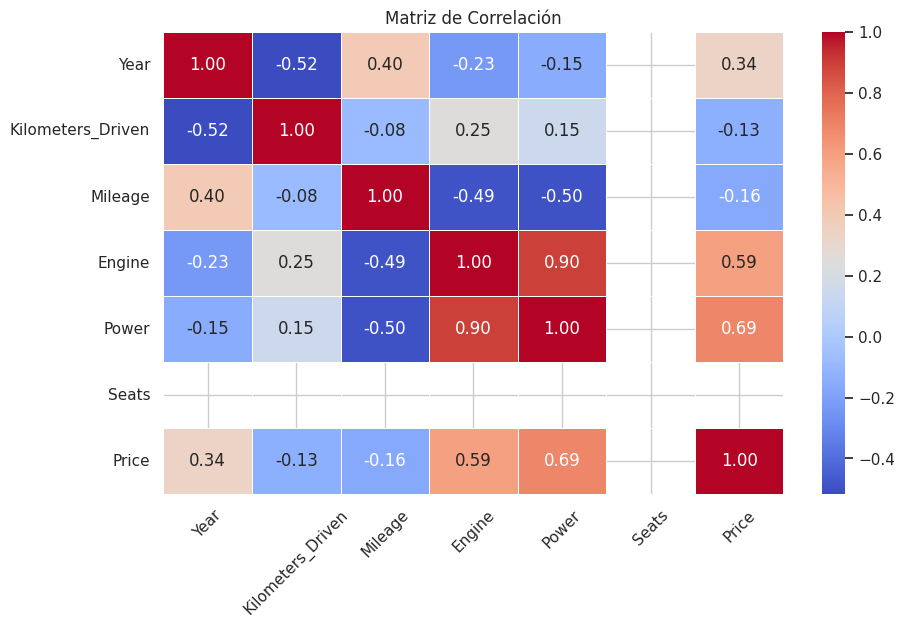

In [ ]:
# 3. Mapa de calor de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean.select_dtypes(include=["float64", "int64"]).corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 4. Gráficos de dispersión entre variables clave
sns.pairplot(df_clean.select_dtypes(include=["float64", "int64"]), diag_kind="kde")
plt.show()

NameError: name 'df_clean' is not defined

1 INR Lakhs equivale a 100,000 rupias o 23432.81 pesos mexicanos


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Otros'),
  Text(1, 0, 'Mumbai'),
  Text(2, 0, 'Hyderabad'),
  Text(3, 0, 'Kochi'),
  Text(4, 0, 'Kolkata')])

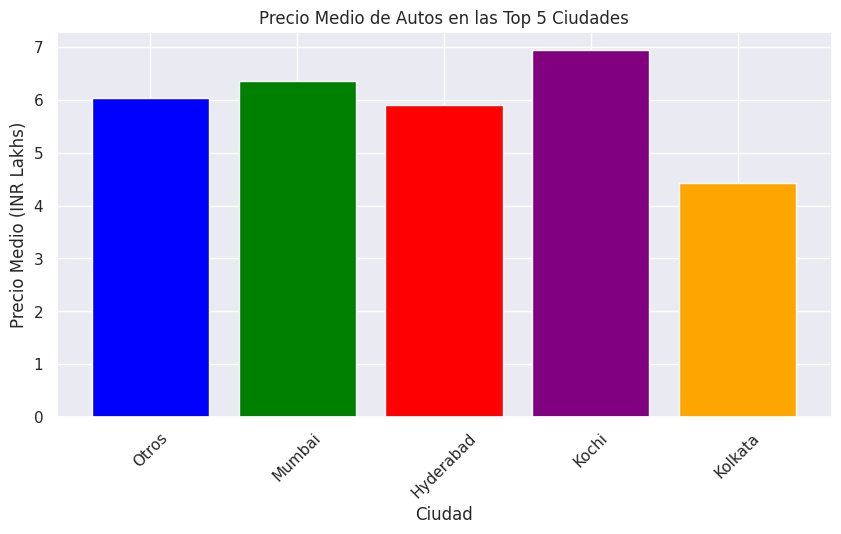

In [ ]:
#Precio medio en las top 5 ciudades
print("1 INR Lakhs equivale a 100,000 rupias o 23432.81 pesos mexicanos")
top_5_ciudades = df["Location"].value_counts().head(5).index
precios_medios = [df[df["Location"] == loc]["Price"].mean() for loc in top_5_ciudades]
plt.figure(figsize=(10, 5))
plt.bar(top_5_ciudades, precios_medios, color=['blue', 'green', 'red', 'purple', 'orange'])
plt.xlabel("Ciudad")
plt.ylabel("Precio Medio (INR Lakhs)")
plt.title("Precio Medio de Autos en las Top 5 Ciudades")
plt.xticks(rotation=45)  # Rotar nombres de ciudades si son largas


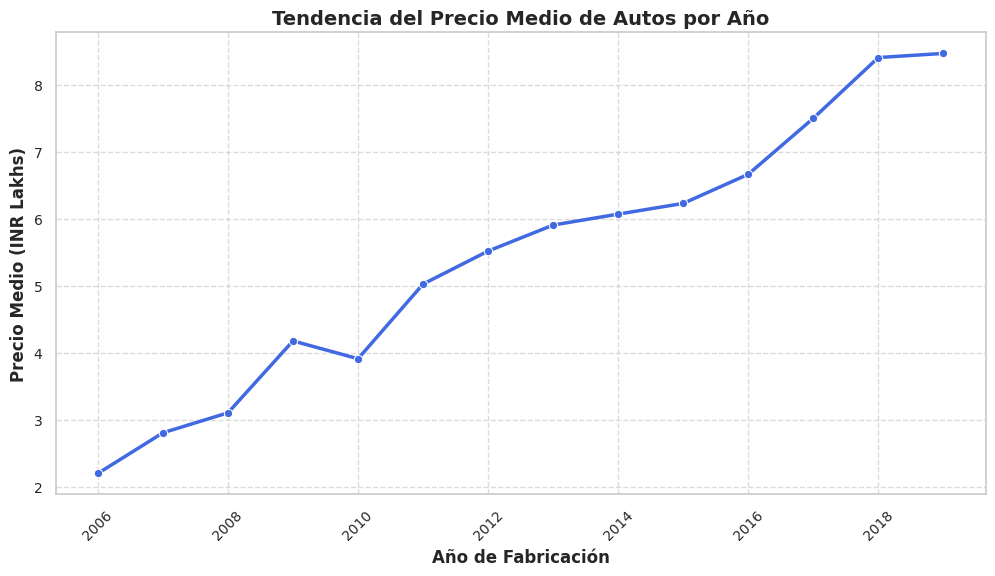

In [ ]:
#precio medio por año
precio_medio_por_año = df.groupby('Year')['Price'].mean()
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

sns.lineplot(x=precio_medio_por_año.index, y=precio_medio_por_año.values, marker='o', color='royalblue', linewidth=2.5)

plt.xlabel('Año de Fabricación', fontsize=12, fontweight='bold')
plt.ylabel('Precio Medio (INR Lakhs)', fontsize=12, fontweight='bold')
plt.title('Tendencia del Precio Medio de Autos por Año', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, fontsize=10)  # Rotar los años si son muchos
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)

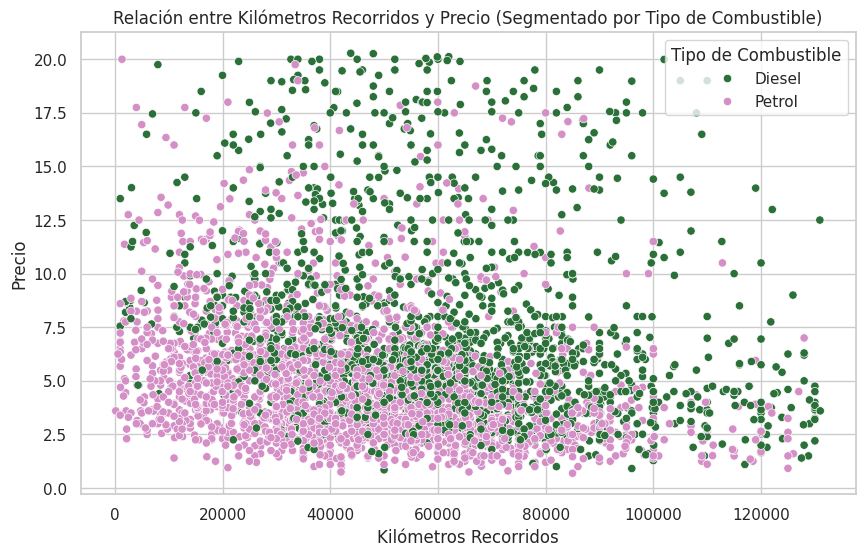

In [ ]:
#Grafico de dispersion de Kilometers_Driben vs Price Segmentado por Fuel_Type

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Kilometers_Driven', y='Price', hue='Fuel_Type', palette='cubehelix')
plt.title('Relación entre Kilómetros Recorridos y Precio (Segmentado por Tipo de Combustible)')
plt.xlabel('Kilómetros Recorridos')
plt.ylabel('Precio')
plt.legend(title='Tipo de Combustible', loc='upper right')